# 3D 表示与数据处理 pipeline 可视化入门

> 配套笔记：[08-3D表示扫盲.md](notes/08-3D表示扫盲.md) ｜ [README.md](notes/README.md)
>
> **目的**：用一个程序生成的 3D "桌子"资产，把它在 **mesh / 点云 / 体素 / SDF / 稀疏体素(SLAT 直觉)** 各种表示之间互相转换并**可视化对比**，让你直观理解：
> - 每种 3D 表示长什么样、装了多少信息；
> - 常见的数据处理方法（采样 / 体素化 / 距离场 / marching cubes）；
> - 为什么"视觉好 ≠ 能进仿真"，以及阅读清单里每篇论文选了哪种表示。

## 表示阶梯（先记住大局）
```
只能看(视觉)        能算几何           能编辑/带材质        能物理交互(sim-ready)
NeRF / 3DGS   →   点云 / 体素 / SDF  →  Mesh + PBR 材质  →  Mesh + 碰撞 + 质量 + 关节(URDF)
```
本 notebook 主要动手玩中间三段（点云/体素/SDF/mesh），NeRF/3DGS 用 2D 示意概念演示。


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import trimesh
import matplotlib.font_manager as fm
from matplotlib import rcParams
_cjk = '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'
try:
    fm.fontManager.addfont(_cjk)
    _name = fm.FontProperties(fname=_cjk).get_name()
    rcParams['font.sans-serif'] = [_name, 'DejaVu Sans']
    rcParams['font.family'] = 'sans-serif'
    rcParams['axes.unicode_minus'] = False
    print('CJK 字体已启用:', _name)
except Exception as e:
    print('CJK 字体未启用(图内中文可能显示为方框):', e)

from scipy import ndimage
from skimage import measure

np.random.seed(0)
plt.rcParams['figure.dpi'] = 110

def set_axes(ax, title=''):
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
    try: ax.set_box_aspect((1,1,1))
    except Exception: pass
    ax.view_init(elev=22, azim=-60)
print('环境就绪:', 'trimesh', trimesh.__version__)


CJK 字体已启用: Noto Sans CJK JP
环境就绪: trimesh 4.12.2


## 步骤 0 · 生成一个基础 3D 资产（一张"桌子"）

我们用 `trimesh` 把 **1 个桌面 + 4 条桌腿**拼成一张桌子——这种家具正是 LiteReality(#5) 这类室内重建研究的典型对象。
它的**原始形态就是 Mesh**（顶点 + 三角面），后面所有表示都从它转换而来。


In [2]:
def make_table():
    parts = []
    # 桌面 (扁平的盒子)
    top = trimesh.creation.box(extents=[1.0, 0.6, 0.06])
    top.apply_translation([0, 0, 0.5])
    parts.append(top)
    # 4 条桌腿
    leg_ext = [0.06, 0.06, 0.5]
    for sx in (-1, 1):
        for sy in (-1, 1):
            leg = trimesh.creation.box(extents=leg_ext)
            leg.apply_translation([sx*0.42, sy*0.22, 0.25])
            parts.append(leg)
    mesh = trimesh.util.concatenate(parts)
    # 归一化到单位立方体中心（3D 生成/重建的常规预处理）
    mesh.apply_translation(-mesh.bounds.mean(axis=0))
    mesh.apply_scale(1.0 / mesh.extents.max())
    return mesh

mesh = make_table()
print(f"顶点数 vertices = {len(mesh.vertices)}")
print(f"面片数 faces    = {len(mesh.faces)}")
print(f"包围盒 extents  = {np.round(mesh.extents,3)}  (已归一化到最大边=1)")
print(f"是否水密 watertight = {mesh.is_watertight}")


顶点数 vertices = 40
面片数 faces    = 60
包围盒 extents  = [1.   0.6  0.53]  (已归一化到最大边=1)
是否水密 watertight = True


## 表示 ① Mesh（三角网格）—— 图形/仿真的"通用货币"

**顶点 + 三角面**。可编辑、可渲染、**加上碰撞体就能进仿真**。
缺点：直接用神经网络生成很难（拓扑不规则）→ 所以生成类论文常"先生成别的表示，再转 mesh"。


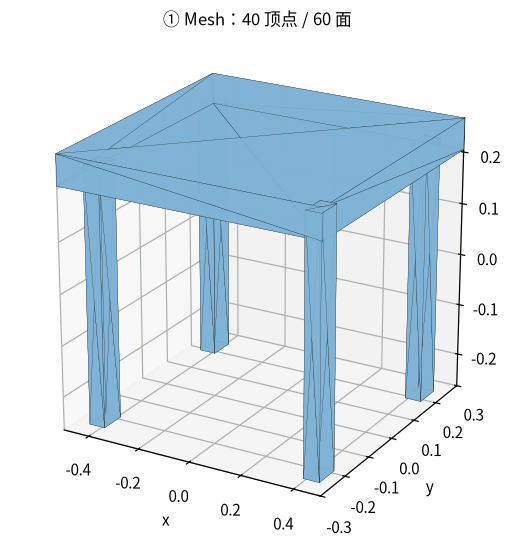

In [3]:
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111, projection='3d')
tri = mesh.vertices[mesh.faces]               # (F,3,3) 每个三角形 3 个顶点
col = Poly3DCollection(tri, alpha=0.9, facecolor='#7fb3d5', edgecolor='k', linewidths=0.15)
ax.add_collection3d(col)
b = mesh.bounds
ax.set_xlim(b[0,0],b[1,0]); ax.set_ylim(b[0,1],b[1,1]); ax.set_zlim(b[0,2],b[1,2])
set_axes(ax, f'① Mesh：{len(mesh.vertices)} 顶点 / {len(mesh.faces)} 面')
plt.tight_layout(); plt.show()


## 表示 ② 点云（Point Cloud）—— 传感器的原始吐出物

深度相机 / LiDAR 扫描**直接输出**的就是点云：一堆 3D 点，**没有面、没有连接关系**。
处理方法：从 mesh 表面**采样(sampling)** 即可得到点云。注意点越少越"稀"，且本身**不能直接渲染/仿真**。


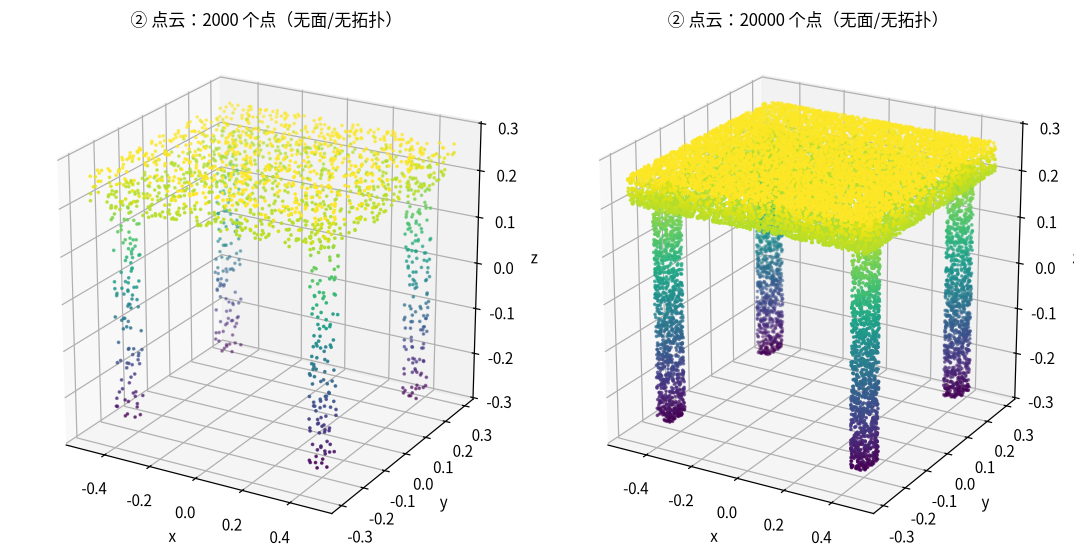

点云 = 只有坐标的散点；要渲染或仿真必须先重建出面(mesh)或转成其它表示。


In [4]:
fig = plt.figure(figsize=(10,5))
for i, n in enumerate([2000, 20000]):
    pts, _ = trimesh.sample.sample_surface(mesh, n)
    ax = fig.add_subplot(1,2,i+1, projection='3d')
    ax.scatter(pts[:,0], pts[:,1], pts[:,2], c=pts[:,2], cmap='viridis', s=2)
    set_axes(ax, f'② 点云：{n} 个点（无面/无拓扑）')
plt.tight_layout(); plt.show()
print('点云 = 只有坐标的散点；要渲染或仿真必须先重建出面(mesh)或转成其它表示。')


## 表示 ③ 体素 / 占据栅格（Voxel / Occupancy）—— 3D 版"像素"

把空间切成 N×N×N 小格，每格标"占据/空"。**对神经网络友好**（像处理图像），
但显存随分辨率 **O(N³) 爆炸**、细节受格子大小限制。下面对比 **16³ vs 32³** 的精度与占用。


16³: 占据率 28.9%  →  稀疏! 大部分格子是空的

32³: 占据率 16.3%  →  稀疏! 大部分格子是空的

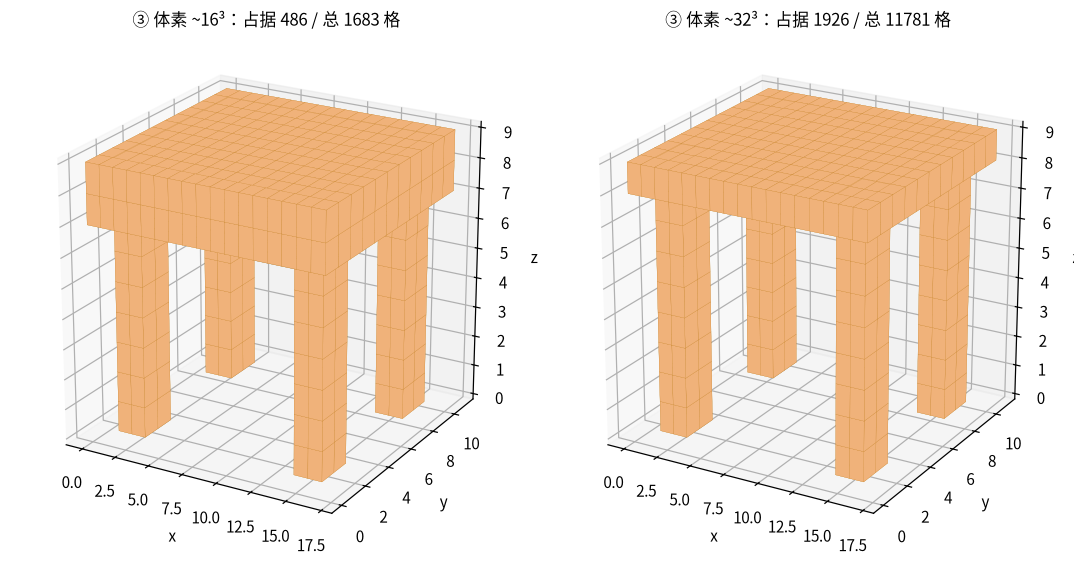

In [5]:
def voxelize(mesh, res):
    pitch = mesh.extents.max() / res
    vg = mesh.voxelized(pitch=pitch).fill()
    return vg.matrix, pitch                    # dense bool (X,Y,Z)

fig = plt.figure(figsize=(10,5))
for i, res in enumerate([16, 32]):
    occ, pitch = voxelize(mesh, res)
    ax = fig.add_subplot(1,2,i+1, projection='3d')
    # ax.voxels 在低分辨率下才不卡，这里用于直观展示
    show = occ if res <= 24 else occ[::2,::2,::2]   # 32³ 抽稀显示
    ax.voxels(show, facecolor='#f0b27a', edgecolor='#b9770e', linewidth=0.1)
    occupied = int(occ.sum()); total = occ.size
    set_axes(ax, f'③ 体素 ~{res}³：占据 {occupied} / 总 {total} 格')
    print(f'{res}³: 占据率 {100*occupied/total:4.1f}%  →  稀疏! 大部分格子是空的')
plt.tight_layout(); plt.show()


## 表示 ④ SDF / 隐式场（Signed Distance Function）

给空间任意点一个"到表面的带符号距离"：**内部为负、外部为正、零等值面 = 物体表面**。
连续、天然水密，但**只能表达封闭实心面**（开放的一张纸、内腔表达不了——这正是 TRELLIS.2(#6) 吐槽 field-based 的点）。

下面我们**从体素占据近似算出一个 SDF**（用距离变换，省去昂贵的逐点最近面查询），
左：一个 z 切片的距离场热力图（红外蓝内，黑线=表面截面）；右：用 **marching cubes** 从 SDF 还原出 mesh。


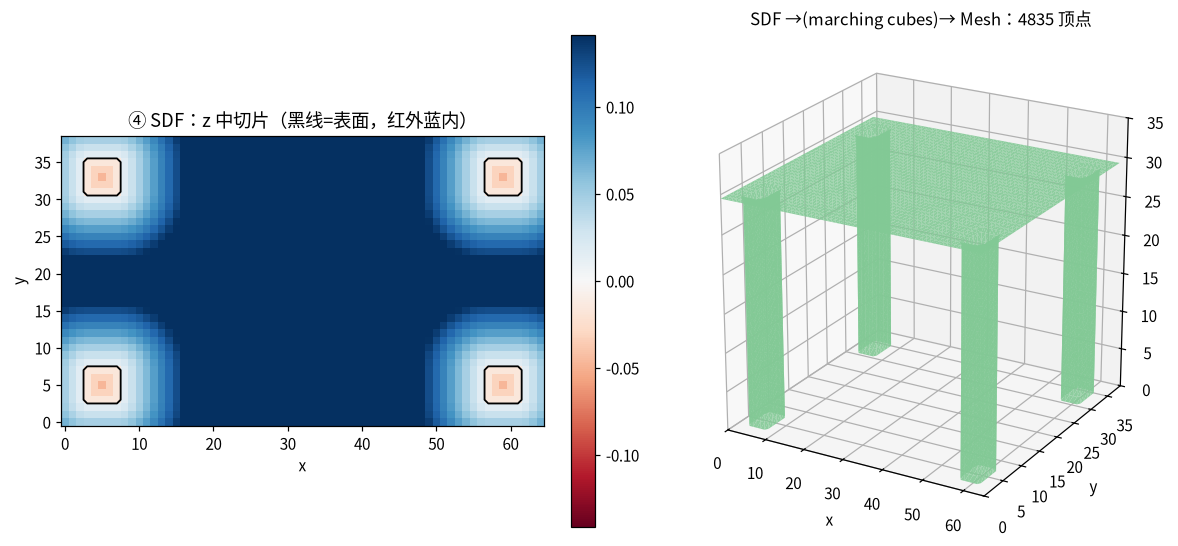

SDF↔Mesh 可互转：marching cubes 是从"标量场"提取等值面的标准方法。


In [6]:
occ, pitch = voxelize(mesh, 64)                       # 64³ 占据
dt_out = ndimage.distance_transform_edt(~occ)         # 外部点到表面的距离
dt_in  = ndimage.distance_transform_edt(occ)          # 内部点到表面的距离
sdf = (dt_out - dt_in) * pitch                        # 负=内部, 正=外部, 0≈表面

fig = plt.figure(figsize=(11,5))
# 左：z 中切片热力图
ax1 = fig.add_subplot(1,2,1)
zc = sdf.shape[2]//2
sl = sdf[:,:,zc].T
im = ax1.imshow(sl, origin='lower', cmap='RdBu', vmin=-sl.std()*2, vmax=sl.std()*2)
ax1.contour(sl, levels=[0], colors='k', linewidths=1.2)   # 零等值面 = 表面
ax1.set_title('④ SDF：z 中切片（黑线=表面，红外蓝内）'); ax1.set_xlabel('x'); ax1.set_ylabel('y')
plt.colorbar(im, ax=ax1, fraction=0.046)
# 右：marching cubes 还原 mesh
verts, faces, _, _ = measure.marching_cubes(sdf, level=0.0)
ax2 = fig.add_subplot(1,2,2, projection='3d')
col = Poly3DCollection(verts[faces], alpha=0.9, facecolor='#82c995', edgecolor='none')
ax2.add_collection3d(col)
ax2.set_xlim(0,sdf.shape[0]); ax2.set_ylim(0,sdf.shape[1]); ax2.set_zlim(0,sdf.shape[2])
set_axes(ax2, f'SDF →(marching cubes)→ Mesh：{len(verts)} 顶点')
plt.tight_layout(); plt.show()
print('SDF↔Mesh 可互转：marching cubes 是从"标量场"提取等值面的标准方法。')


## 表示 ⑤ 稀疏体素 + 特征（SLAT / O-Voxel 的直觉）

TRELLIS 的 **SLAT** / TRELLIS.2 的 **O-Voxel** 就是：**只保留占据的体素**（稀疏），
并给每个占据体素附一个**特征向量**（几何/颜色/材质）。这就是 #1/#2/#3/#6 生成类的"工作表示"。

下面：把占据体素的中心画出来，**颜色 = 该体素的局部特征**（这里用法线方向近似），
并算一下"稀疏"省了多少：只存占据格 vs 存满 N³。


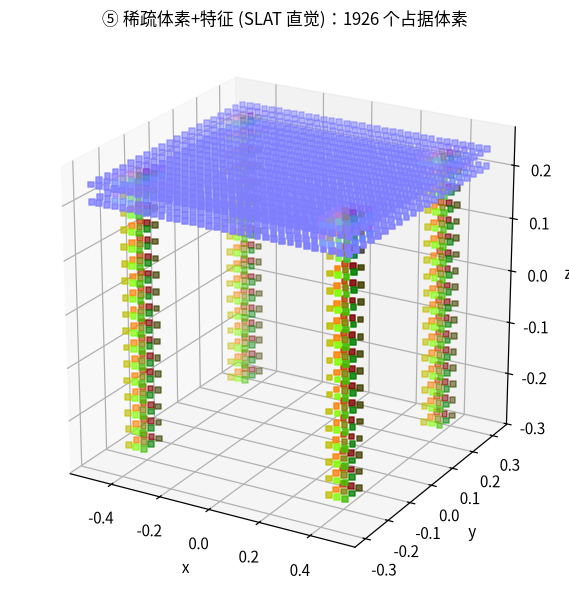

稠密 32³ 需要 32,768 格；稀疏只存 1,926 个占据格 → 压缩 17.0×（这就是稀疏表示能上高分辨率的原因）


In [7]:
res = 32
occ, pitch = voxelize(mesh, res)
idx = np.argwhere(occ)                                  # 占据体素的 (i,j,k)
centers = idx * pitch + mesh.bounds[0]                  # 转回世界坐标
# 用"到表面梯度"近似每个体素的法线作为特征着色
gx, gy, gz = np.gradient(ndimage.distance_transform_edt(occ).astype(float))
feat = np.stack([gx[tuple(idx.T)], gy[tuple(idx.T)], gz[tuple(idx.T)]], axis=1)
feat = (feat - feat.min(0)) / (np.ptp(feat,0)+1e-9)     # 归一化到 [0,1] 当 RGB

fig = plt.figure(figsize=(5.5,5.5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(centers[:,0], centers[:,1], centers[:,2], c=feat, s=14, marker='s')
set_axes(ax, f'⑤ 稀疏体素+特征 (SLAT 直觉)：{len(idx)} 个占据体素')
plt.tight_layout(); plt.show()

dense = res**3
print(f'稠密 {res}³ 需要 {dense:,} 格；稀疏只存 {len(idx):,} 个占据格 '
      f'→ 压缩 {dense/len(idx):.1f}×（这就是稀疏表示能上高分辨率的原因）')


## 步骤 6 · 把整条"数据处理 pipeline"串起来看

一行展示常见转换链：**Mesh → 点云(采样) → 体素(体素化) → SDF(距离场) → Mesh(marching cubes)**。
这正是 3D 学习里反复出现的几个基本操作。


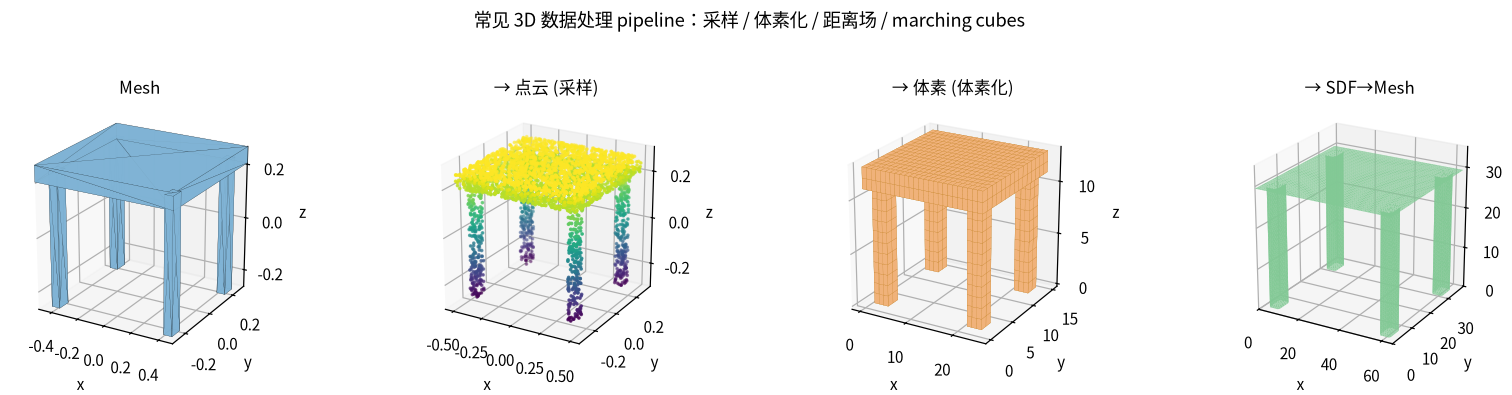

In [8]:
fig = plt.figure(figsize=(15,3.2))
# 1 mesh
ax = fig.add_subplot(1,4,1, projection='3d')
ax.add_collection3d(Poly3DCollection(mesh.vertices[mesh.faces], alpha=.9, facecolor='#7fb3d5', edgecolor='k', linewidths=.1))
b=mesh.bounds; ax.set_xlim(b[0,0],b[1,0]); ax.set_ylim(b[0,1],b[1,1]); ax.set_zlim(b[0,2],b[1,2]); set_axes(ax,'Mesh')
# 2 point cloud
pts,_ = trimesh.sample.sample_surface(mesh, 4000)
ax = fig.add_subplot(1,4,2, projection='3d')
ax.scatter(pts[:,0],pts[:,1],pts[:,2],c=pts[:,2],cmap='viridis',s=2); set_axes(ax,'→ 点云 (采样)')
# 3 voxel
occ24,_ = voxelize(mesh, 24)
ax = fig.add_subplot(1,4,3, projection='3d')
ax.voxels(occ24, facecolor='#f0b27a', edgecolor='#b9770e', linewidth=.1); set_axes(ax,'→ 体素 (体素化)')
# 4 sdf->mesh
ax = fig.add_subplot(1,4,4, projection='3d')
ax.add_collection3d(Poly3DCollection(verts[faces], alpha=.9, facecolor='#82c995', edgecolor='none'))
ax.set_xlim(0,sdf.shape[0]); ax.set_ylim(0,sdf.shape[1]); ax.set_zlim(0,sdf.shape[2]); set_axes(ax,'→ SDF→Mesh')
plt.suptitle('常见 3D 数据处理 pipeline：采样 / 体素化 / 距离场 / marching cubes', y=1.04)
plt.tight_layout(); plt.show()


## 表示 ⑥⑦ NeRF / 3DGS —— "视觉派"（概念演示）

NeRF / 3DGS 是从**多视角照片**重建"能换视角看"的场景，偏**视觉真实**但**没有显式几何/物理**。
它们需要训练，这里用一个 **2D 示意**说明 3DGS 的核心直觉：
**点云是"硬点"，而 3DGS 把每个点换成一个有大小/不透明度的"软高斯斑"**，叠加(splatting)后画面更连续真实。


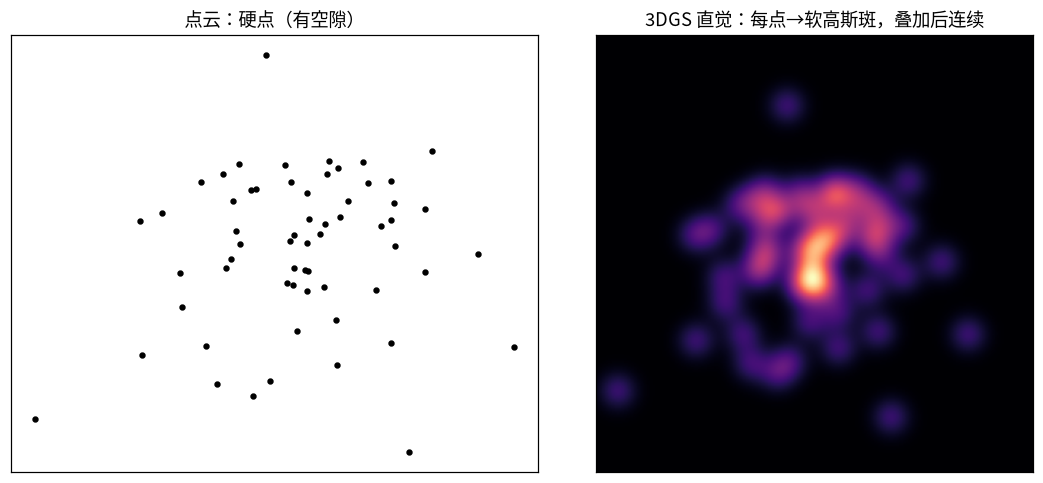

真实 3DGS 是 3D 各向异性高斯 + 可微光栅化；GS-Playground(#4) 用它做高吞吐仿真渲染。


In [9]:
rng = np.random.default_rng(1)
P = rng.normal(0,1,(60,2))                # 一些 2D 点
fig, axes = plt.subplots(1,2, figsize=(10,4.5))
axes[0].scatter(P[:,0],P[:,1], s=10, c='k'); axes[0].set_title('点云：硬点（有空隙）')
# splatting: 把每个点画成软高斯斑叠加
gx, gy = np.mgrid[-3:3:300j, -3:3:300j]
img = np.zeros_like(gx)
for (px,py) in P:
    img += np.exp(-((gx-px)**2+(gy-py)**2)/(2*0.18**2))
axes[1].imshow(img.T, origin='lower', extent=[-3,3,-3,3], cmap='magma')
axes[1].set_title('3DGS 直觉：每点→软高斯斑，叠加后连续')
for a in axes: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()
print('真实 3DGS 是 3D 各向异性高斯 + 可微光栅化；GS-Playground(#4) 用它做高吞吐仿真渲染。')


## 总结 · 哪种表示能干什么 & 清单里谁用

| 表示 | 直接渲染 | 显式几何 | 可编辑 | 能进仿真(碰撞/物理) | 清单里谁用 |
|---|:--:|:--:|:--:|:--:|---|
| **Mesh** | ✅ | ✅ | ✅ | ✅(加碰撞) | 所有论文最终输出 |
| **点云** | ❌ | ⚠️无面 | ❌ | ❌ | Real2Sim 输入 |
| **体素/占据** | ❌ | ✅(粗) | ⚠️ | ⚠️转mesh后 | PhysX 系、TRELLIS 底子 |
| **SDF/隐式场** | ❌ | ✅(水密) | ❌ | ⚠️转mesh后 | 多数生成几何底座 |
| **NeRF** | ✅(慢) | ❌一团 | ❌ | ❌ | 背景/对比 |
| **3DGS** | ✅(快) | ❌偏表面 | ⚠️ | ❌(需另配几何) | GS-Playground #4 |
| **SLAT/O-Voxel** | ❌(需解码) | ✅ | ⚠️ | ⚠️解码+加物理 | TRELLIS.2 #6 + 生成类骨干 |
| **URDF/MJCF/USD** | (取决mesh) | ✅ | ✅ | ✅✅ **为它而生** | PhysX-Anything/PAct 导出 |

**一句话**：要"好看"选 3DGS/NeRF；要"能生成"选 体素/SLAT；要"能进仿真"最终都得落到 **Mesh + 碰撞** 并导出 **URDF/MJCF/USD**。

### 想继续深入？（代码都在 ../code/）
- **体素↔mesh 真实实现**：`TRELLIS.2/o-voxel/examples/mesh2ovox.py`、`ovox2mesh.py`
- **生成→URDF→MuJoCo**：`PhysX-Anything/` 的 `1_vlm_demo.py … render_urdf.py`
- **3DGS 剪枝**：`GS-Playground/benchmark/scripts/prune_gaussians.py`

> 配套阅读：[08-3D表示扫盲.md](notes/08-3D表示扫盲.md)（表示速查）+ [README.md](notes/README.md)（领域入门 + 7 篇论文精读）
